In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [7]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import RANK
import linear
from aux_ import choose_gpu, next_states_quad
from model_funcs import euler_error, NKPC_error

### Choose device

In [8]:
device = choose_gpu()

choosing cpu


# OccBin

In [39]:
model = RANK.RANK_model(device)

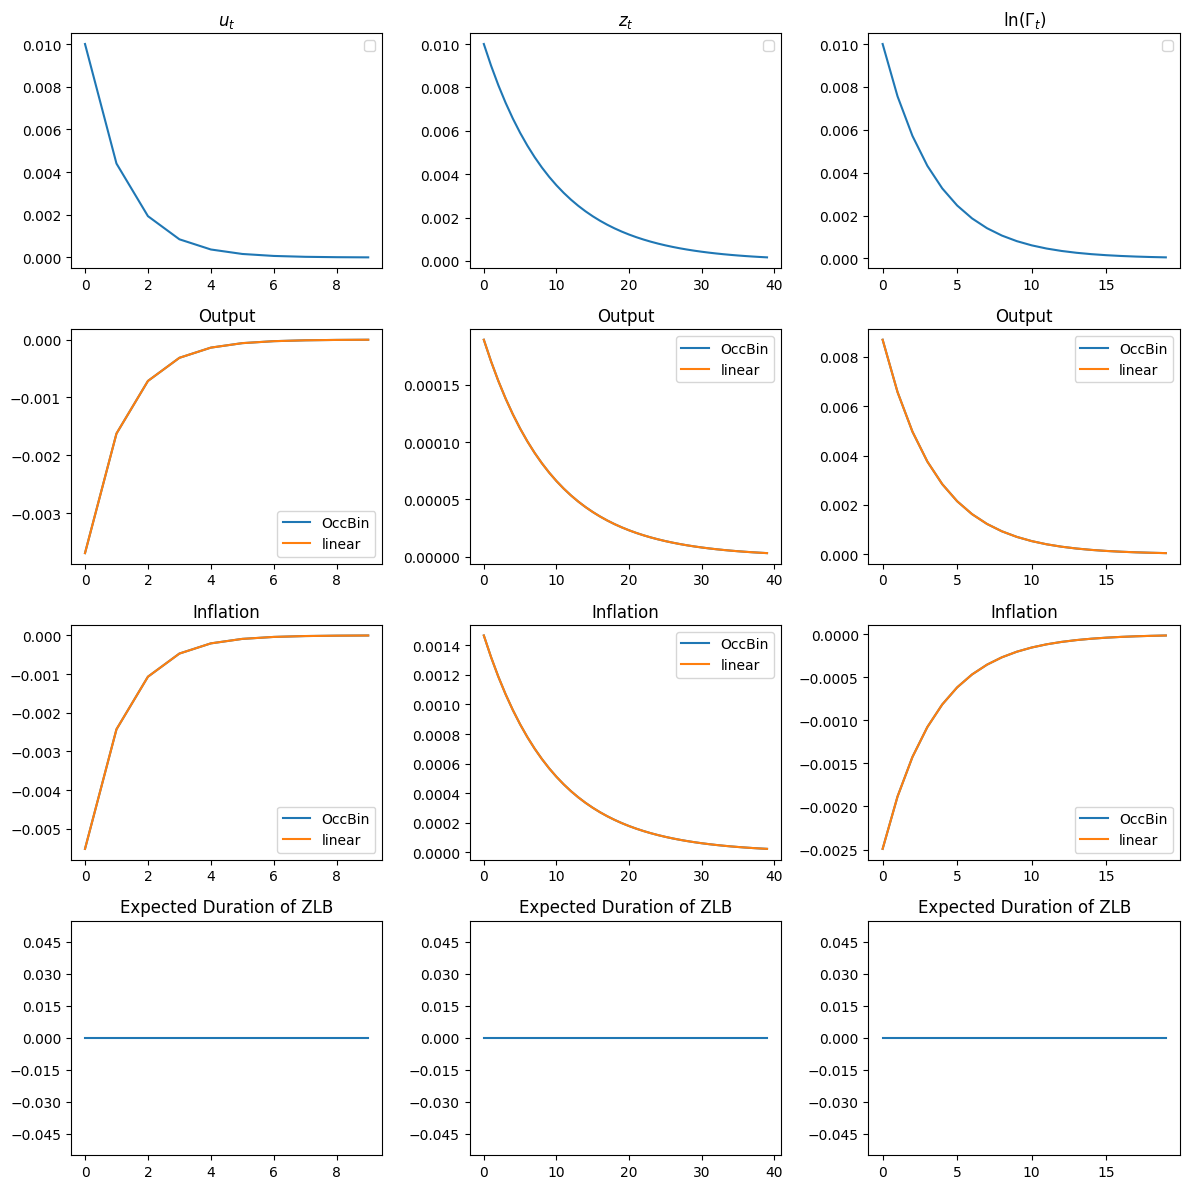

In [40]:
linear.compute_linear_IRFs(model, 0.01, 50)
linear.plot_linear_IRFs(model, plot_exp_T=True)

In [41]:
sigma_quad = {
    "sigma_eps_u" : 0.0085,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

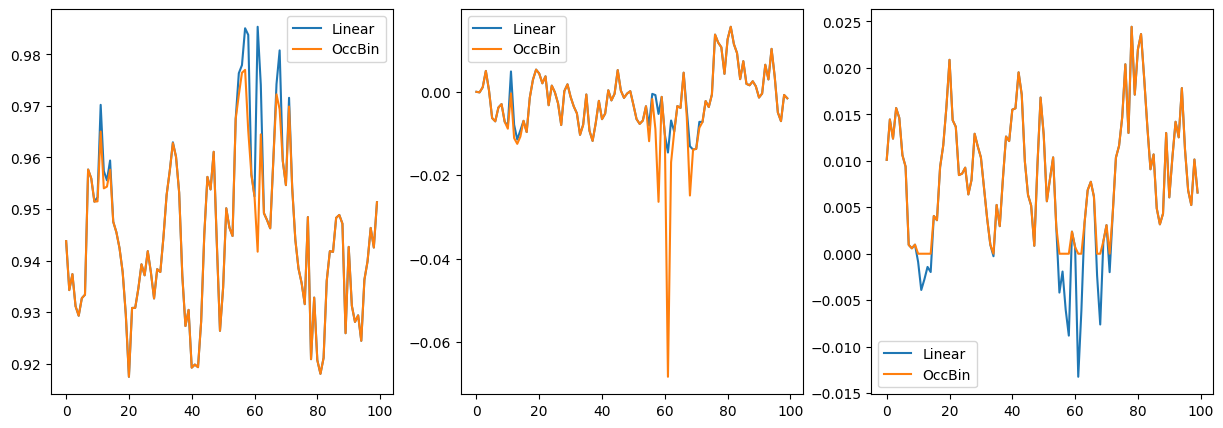

In [42]:
linear.simulate_linear(model, sigma_quad, 100, plot=True)

In [43]:
model.linear["P_ZLB_hist"]

Array([[[-3.91753733e-01,  2.35942557e-01,  4.79368359e-01],
        [-5.70878029e-01,  3.29619735e-01, -5.78220844e-01]],

       [[-4.09433842e-01,  5.86702108e-01, -5.01458868e-02],
        [-5.94010115e-01,  7.88543224e-01, -1.27102160e+00]],

       [[-4.26818937e-01,  1.29219210e+00, -9.44647014e-01],
        [-6.18749857e-01,  1.79248726e+00, -2.54393697e+00]],

       [[-4.44741726e-01,  2.77987647e+00, -2.52889323e+00],
        [-6.44643426e-01,  3.94178391e+00, -4.83273888e+00]],

       [[-4.63380307e-01,  5.94439077e+00, -5.35924721e+00],
        [-6.71643317e-01,  8.52590656e+00, -8.93279648e+00]],

       [[-4.82793212e-01,  1.26861763e+01, -1.04236765e+01],
        [-6.99778199e-01,  1.82966976e+01, -1.62726135e+01]],

       [[-5.03018141e-01,  2.70530243e+01, -1.94880753e+01],
        [-7.29092419e-01,  3.91201439e+01, -2.94106369e+01]],

       [[-5.24090171e-01,  5.76704826e+01, -3.57124672e+01],
        [-7.59634852e-01,  8.34980316e+01, -5.29267731e+01]],

       [

# Errors

In [8]:
sigma = 0.00001

gh_x, gh_w = construct_gh_nodes(model.dtype, 4, sigma, sigma, sigma)

states_p = next_states_quad(model.par, model.dtype, states, gh_x)

NameError: name 'construct_gh_nodes' is not defined

In [ ]:
P, A, B, C, D, K = linear.compute_linear_policy(model.par, ZLB_regime=False)
P_ZLB, A_ZLB, B_ZLB, C_ZLB, D_ZLB, K_ZLB = linear.compute_linear_policy(model.par, ZLB_regime=True)

In [ ]:
X_p = linear.OccBin(model.par, model.linear, states_p.reshape(-1,3),)

In [ ]:
X_p = X_p.reshape(2000, 64, 2)

In [ ]:
Y = X[:, 0]
pi = X[:, 1]

Y_p = X_p[..., 0]
pi_p = X_p[..., 1]

u = states[:, 0]
z = states[:, 1]
ln_Gamma = states[:, 2]

eps_z = gh_x[:, 1]

ee = euler_error(
    model.par, Y, Y_p, pi, pi_p, u, z, eps_z, gh_w
)

nkpce = NKPC_error(model.par, Y, Y_p, pi, pi_p, u, ln_Gamma, gh_w)

(-0.25, 0.25)

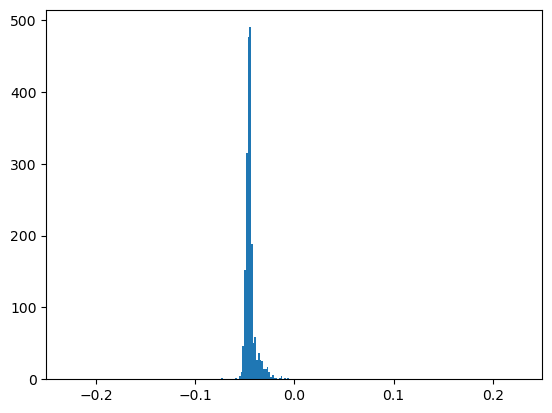

In [ ]:
plt.hist(nkpce, bins=200)
plt.xlim([-0.25, 0.25])

(-2.5, 0.5)

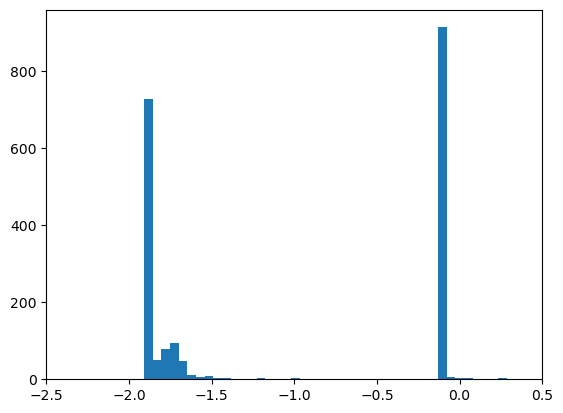

In [ ]:
plt.hist(ee, bins=500)
plt.xlim([-2.5, 0.5])

In [ ]:
print(nkpce.mean())
print(ee.mean())

-0.044561036
-0.99312687


In [ ]:
Y_inp, pi_inp = linear.compute_OccBin_on_grid(model, 200, 0.01)

AttributeError: module 'linear' has no attribute 'compute_OccBin_on_grid'

In [ ]:
u_grid_expanded = jnp.concatenate([np.linspace(-0.04, 0.04, 100)[:, None], jnp.zeros((100,1)), jnp.zeros((100,1))])

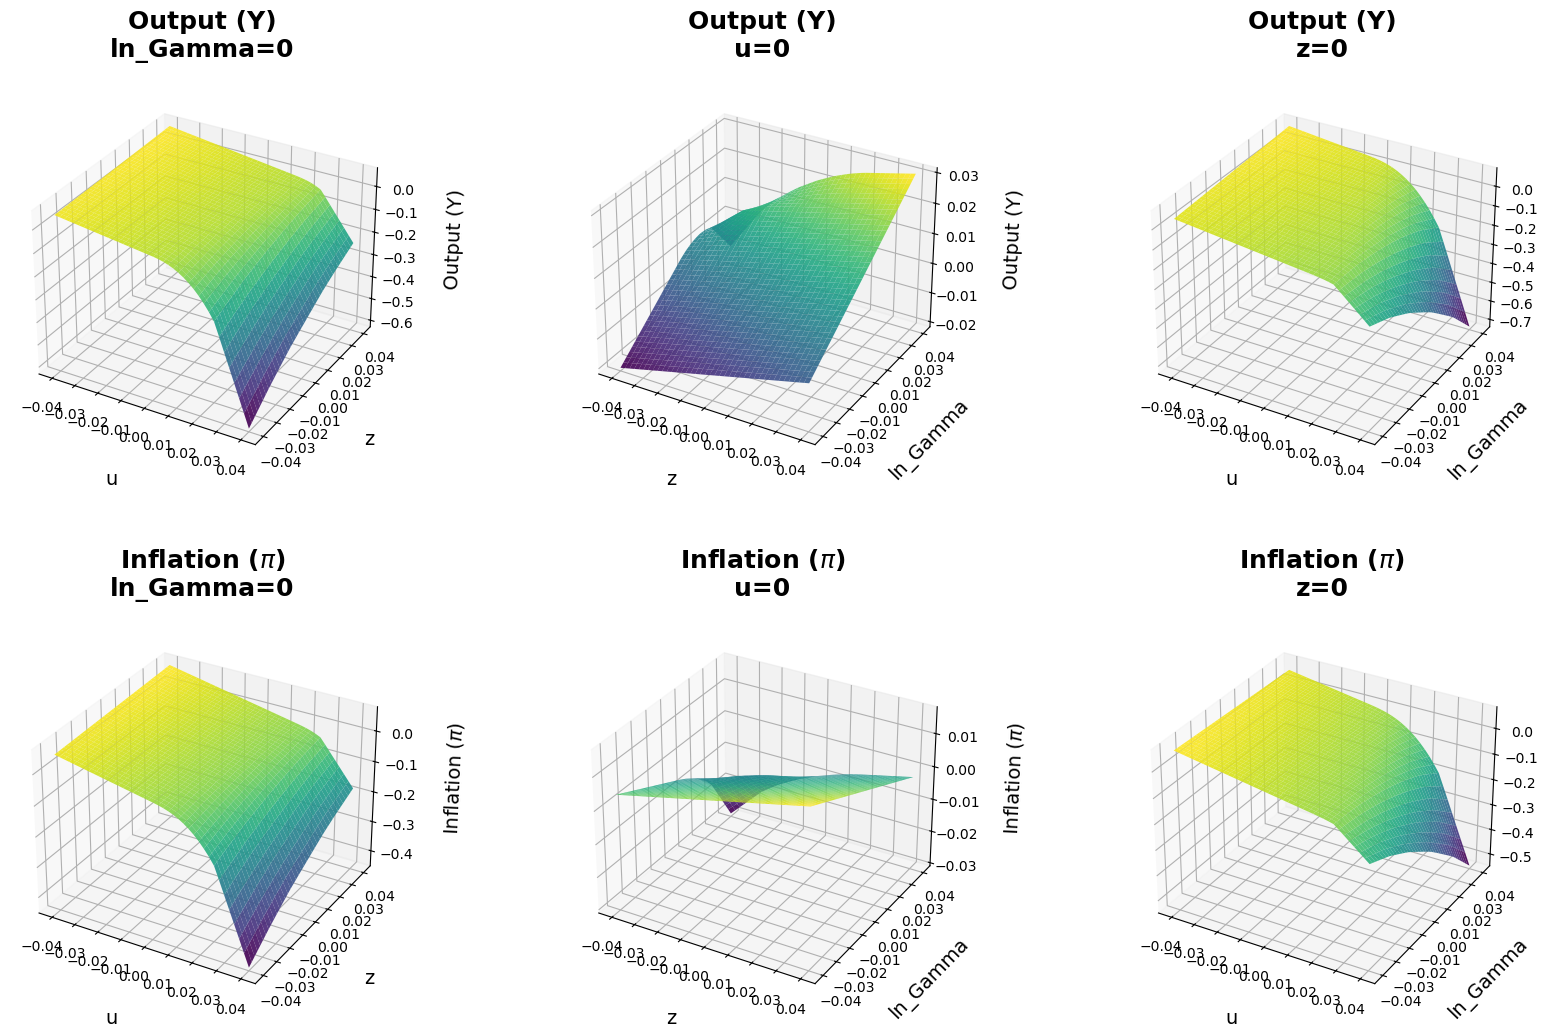

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Justér globale tekststørrelser for en start
plt.rcParams.update({'font.size': 12}) 

n_points = 40
vals = np.linspace(-0.04, 0.04, n_points)
X, Y_grid = np.meshgrid(vals, vals)
zeros = np.zeros_like(X)

def plot_3d_subplot(ax, x_data, y_data, z_data, title, xlabel, ylabel, zlabel):
    surf = ax.plot_surface(x_data, y_data, z_data, cmap='viridis', edgecolor='none', alpha=0.9)
    
    # Gør titlen stor og tydelig
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Labels med stor tekst og afstand (labelpad)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=15)
    ax.set_zlabel(zlabel, fontsize=14, labelpad=15)
    
    # Gør tallene på akserne (ticks) større
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Zoom lidt ind ved at reducere afstanden (dist)
    ax.dist = 11 
    
    return surf

# Vi gør selve figuren endnu større (20x12 tommer)
fig = plt.figure(figsize=(20, 12))

planes = [
    (X, Y_grid, zeros, 'u', 'z', 'ln_Gamma=0'),
    (zeros, X, Y_grid, 'z', 'ln_Gamma', 'u=0'),
    (X, zeros, Y_grid, 'u', 'ln_Gamma', 'z=0')
]

# Bruger dine navne Y_inp og pi_inp fra koden
for row, (interp, label) in enumerate([(Y_inp, 'Output (Y)'), (pi_inp, 'Inflation ($\pi$)')]):
    for col, (u_dim, z_dim, g_dim, xlab, ylab, subtitle) in enumerate(planes):
        pts = np.stack([u_dim.ravel(), z_dim.ravel(), g_dim.ravel()], axis=-1)
        res = interp(pts).reshape(X.shape)
        
        ax = fig.add_subplot(2, 3, row * 3 + col + 1, projection='3d')
        
        # Bestem hvilke data der skal på x/y aksen i plottet
        x_p = u_dim if col != 1 else z_dim
        y_p = z_dim if col == 0 else g_dim
        
        plot_3d_subplot(ax, x_p, y_p, res, f'{label}\n{subtitle}', xlab, ylab, label)

# Mere luft mellem rækker og kolonner så teksten ikke overlapper
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

# OccBin Example

Consider the simple model of one state variable: $u_t=0.9*u_{t-1}+ \epsilon^u_t \Rightarrow \mathbb{E}_t[u_{t+1}]=0.9* u_t$:

$$\begin{align*}
Y_{t+1}+\sigma \pi_{t+1}-Y_t-\sigma \phi \pi_t - \sigma u_t &= 0 \\
\beta \pi_{t+1} + \kappa Y_t - \pi_t &= 0 \\
\ \\
\Rightarrow \begin{bmatrix} 1 & \sigma \\ 0 & \beta \end{bmatrix} \begin{bmatrix} Y_{t+1} \\ \pi_{t+1} \end{bmatrix} + \begin{bmatrix} -1 & -\sigma \phi \\ \kappa & -1  \end{bmatrix}   \begin{bmatrix} Y_{t} \\ \pi_{t} \end{bmatrix} +  \begin{bmatrix} -\sigma \\ 0 \end{bmatrix} u_t &= 0
\end{align*} \\ \ \\
\Rightarrow  A  =  \begin{bmatrix} 1 & \sigma \\ 0 & \beta \end{bmatrix} \\
\Rightarrow B = \begin{bmatrix} -1 & -\sigma \phi \\ \kappa & -1  \end{bmatrix} \\
\Rightarrow C = \begin{bmatrix} -\sigma \\ 0 \end{bmatrix} $$
Under ZLB we have (in deviations from DSS): $i_t=i_{ZLB}=1-1/\beta$

$$\begin{align*}
Y_{t+1}+\sigma \pi_{t+1}-Y_t-\sigma i_{ZLB} &= 0 \\
\beta \pi_{t+1} + \kappa Y_t - \pi_t &= 0 \\
\ \\
\Rightarrow \begin{bmatrix} 1 & \sigma \\ 0 & \beta \end{bmatrix} \begin{bmatrix} Y_{t+1} \\ \pi_{t+1} \end{bmatrix} + \begin{bmatrix} -1 & 0 \\  \kappa & -1  \end{bmatrix}   \begin{bmatrix} Y_{t} \\ \pi_{t} \end{bmatrix} +  \begin{bmatrix} 1-1/\beta \\ 0 \end{bmatrix} &= 0
\end{align*} \\ \ \\
\Rightarrow  A  =  \begin{bmatrix} 1 & \sigma \\ 0 & \beta \end{bmatrix} \\
\Rightarrow B = \begin{bmatrix} -1 & 0 \\ \kappa & -1  \end{bmatrix} \\
\Rightarrow C = \begin{bmatrix} 0 \\ 0 \end{bmatrix} \\
\Rightarrow D = \begin{bmatrix} \sigma(1/\beta-1) \\ 0 \end{bmatrix} $$

In [ ]:
beta = 0.99
sigma = 2.0
kappa = 0.05
phi = 1.5
rho_u = 0.9

A = jnp.array([
    [1, sigma],
    [0, beta]
])

B = jnp.array([
    [-1, -sigma*phi],
    [kappa, -1]
])

C = jnp.array([
    [-sigma],
    [0]
])

$$A \mathbb{E}_t[X_{t+1}]+BX_t+Cu_t = 0$$
$$A P\rho^u u_t+BPu_t+Cu_t = 0$$
$$A P\rho^u +BP+C = 0$$
$$(A\rho^u+B)P = -C$$
$$P = -(A\rho^u+B)^{-1} C$$

In [ ]:
P = -jnp.linalg.inv(A*rho_u + B)@C
d = jnp.zeros((2,1))

In [ ]:
A_ZLB = jnp.array([
    [1, sigma],
    [0, beta]
])

B_ZLB = jnp.array([
    [-1, 0],
    [kappa, -1]
])

C_ZLB = jnp.array([
    [0],
    [0]
])

D_ZLB = jnp.array([
    [sigma*(1/beta-1)],
    [0]
])


Under ZLB:
$$A \mathbb{E}_t[X_{t+1}]+BX_t+Cu_t+ D = 0$$
$$A P\rho^u u_t+Ad+BPu_t+Bd+Cu_t + D = 0$$
$$((A\rho^u +B)P+C)u_t+(Ad+Bd+D)$$

In [ ]:
P_ZLB = -jnp.linalg.inv(A_ZLB*rho_u + B_ZLB)@C_ZLB
d_ZLB = -jnp.linalg.inv(A_ZLB + B_ZLB) @ D_ZLB

In [ ]:
maxT = 5

P_hist = jnp.zeros((maxT, 2, 1)) + jnp.nan
d_hist = jnp.zeros((maxT, 2, 1)) + jnp.nan

# Guess T = 1
P_T1 = - jnp.linalg.solve(B_ZLB, A_ZLB @ P * rho_u + C_ZLB)
d_T1 = - jnp.linalg.solve(B_ZLB, A @ d + D_ZLB)
P_hist = P_hist.at[0].set(P_T1)
d_hist = d_hist.at[0].set(d_T1)

# Guess T = 2
P_T2 = - jnp.linalg.solve(B_ZLB, A_ZLB @ P_T1 * rho_u + C_ZLB)
d_T2 = - jnp.linalg.solve(B_ZLB, A @ d_T1 + D_ZLB)
P_hist = P_hist.at[1].set(P_T2)
d_hist = d_hist.at[1].set(d_T2)

# Guess T = 3
P_T3 = - jnp.linalg.solve(B_ZLB, A_ZLB @ P_T2 * rho_u + C_ZLB)
d_T3 = - jnp.linalg.solve(B_ZLB, A @ d_T2 + D_ZLB)
P_hist = P_hist.at[2].set(P_T3)
d_hist = d_hist.at[2].set(d_T3)

# Guess T = 4
P_T4 = - jnp.linalg.solve(B_ZLB, A_ZLB @ P_T3 * rho_u + C_ZLB)
d_T4 = - jnp.linalg.solve(B_ZLB, A @ d_T3 + D_ZLB)
P_hist = P_hist.at[3].set(P_T4)
d_hist = d_hist.at[3].set(d_T4)

# Guess T = 5
P_T5 = - jnp.linalg.solve(B_ZLB, A_ZLB @ P_T4 * rho_u + C_ZLB)
d_T5 = - jnp.linalg.solve(B_ZLB, A @ d_T4 + D_ZLB)
P_hist = P_hist.at[4].set(P_T5)
d_hist = d_hist.at[4].set(d_T5)


In [ ]:
# simulate a u


def OccBin_toy(u):
    # compute non-ZLB policy
    Y_t, pi_t = P @ u
    i_t_shadow = phi*pi_t + u

    if not i_t_shadow < -(1/beta-1):
        print('ZLB does not bind, all linear')
    else:
        print(f'ZLB binds, continuing to shooting algorithm: shadow interest rate is {i_t_shadow[0,0]:.4f} < {-1/beta+1:.4f}')

        # policy if it binds for T = 1 periods
        Y_t, pi_t = P_hist[0] * u + d_hist[0]

        # check that we are out of ZLB in period t+T = t+1
        u = rho_u*u
        Y_t_plus_1, pi_t_plus_1 = P * u

        i_t_plus_1_shadow = phi*pi_t_plus_1 + u

        if i_t_plus_1_shadow > -(1/beta-1):
            print('ZLB binds 1 period, linear from T = 1 -> done')

        else:
            print(f'ZLB binds more than 1 period -> continuing shooting: shadow interest rate is {i_t_plus_1_shadow[0,0]:.4f} < {-1/beta+1:.4f}')

            Y_t, pi_t = P_hist[1] * u + d_hist[1]

            u = rho_u*u
            Y_t_plus_2, pi_t_plus_2 = P * u

            i_t_plus_2_shadow = phi*pi_t_plus_2 + u

            if i_t_plus_2_shadow > -(1/beta-1):
                print('ZLB binds 2 periods, linear from T = 2 -> done')

            else:
                print(f'ZLB binds more than 2 periods -> continuing shooting: shadow interest rate is {i_t_plus_2_shadow[0,0]:.4f} < {-1/beta+1:.4f}')

                Y_t, pi_t = P_hist[2] * u + d_hist[2]

                u = rho_u*u
                Y_t_plus_3, pi_t_plus_3 = P * u

                i_t_plus_3_shadow = phi*pi_t_plus_3 + u

                if i_t_plus_3_shadow > -(1/beta-1):
                    print(f'ZLB binds 3 periods, linear from T = 3 -> done')

                else:
                    print(f'ZLB binds more than 3 periods -> continuing shooting: shadow interest rate is {i_t_plus_3_shadow[0,0]:.4f} < {-1/beta+1:.4f}')

                    Y_t, pi_t = P_hist[3] * u + d_hist[3]

                    u = rho_u*u
                    Y_t_plus_4, pi_t_plus_4 = P * u
                    i_t_plus_4_shadow = phi*pi_t_plus_4

                    if i_t_plus_4_shadow > -(1/beta-1):
                        print(f'ZLB binds 4 periods, linear from T = 4 -> done')
                    else:
                        print(f'NOT SOLVED')

    return Y_t, pi_t

In [ ]:
u = jnp.array([
    [0.01]
])

In [ ]:
OccBin_toy(u)

ZLB binds, continuing to shooting algorithm: shadow interest rate is -0.0112 < -0.0101
ZLB binds 1 period, linear from T = 1 -> done


(Array([0.04907692], dtype=float32), Array([-0.00364505], dtype=float32))

In [ ]:
u0 = jnp.array([
    [0.00]
])

key = jax.random.PRNGKey(42)

T = 20
Y = jnp.zeros(T)
pi = jnp.zeros(T)

Y_lin = jnp.zeros(T)
pi_lin = jnp.zeros(T)

u = u0
u_array = jnp.zeros(T)
u_array = u_array.at[0].set(u0[0,0])

for t in range(T):

    subkey, key = jax.random.split(key)
    u = rho_u * u + 0.003*jax.random.normal(key)
    u_array = u_array.at[t].set(u[0,0])

    Y_t, pi_t = OccBin_toy(u)
    
    Y = Y.at[t].set(Y_t[0])
    pi = pi.at[t].set(pi_t[0])

    Y_lin_t, pi_lin_t = P*u
    Y_lin = Y_lin.at[t].set(Y_lin_t[0])
    pi_lin = pi_lin.at[t].set(pi_lin_t[0])

ZLB does not bind, all linear
ZLB does not bind, all linear
ZLB does not bind, all linear
ZLB does not bind, all linear
ZLB binds, continuing to shooting algorithm: shadow interest rate is -0.0127 < -0.0101
ZLB binds more than 1 period -> continuing shooting: shadow interest rate is -0.0115 < -0.0101
ZLB binds more than 2 periods -> continuing shooting: shadow interest rate is -0.0103 < -0.0101
ZLB binds 3 periods, linear from T = 3 -> done
ZLB binds, continuing to shooting algorithm: shadow interest rate is -0.0116 < -0.0101
ZLB binds more than 1 period -> continuing shooting: shadow interest rate is -0.0105 < -0.0101
ZLB binds 2 periods, linear from T = 2 -> done
ZLB binds, continuing to shooting algorithm: shadow interest rate is -0.0137 < -0.0101
ZLB binds more than 1 period -> continuing shooting: shadow interest rate is -0.0123 < -0.0101
ZLB binds more than 2 periods -> continuing shooting: shadow interest rate is -0.0111 < -0.0101
ZLB binds 3 periods, linear from T = 3 -> done
Z

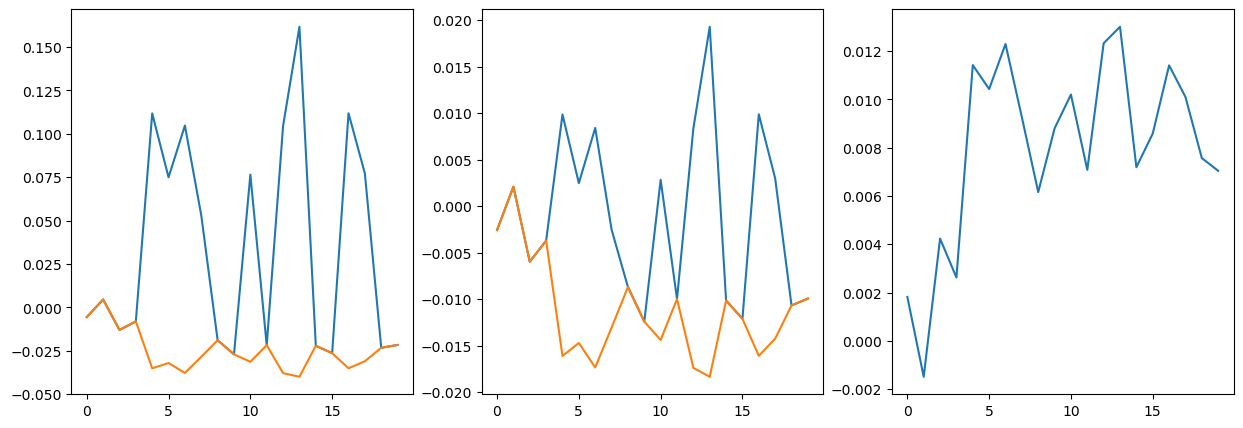

In [ ]:
f, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].plot(Y)
ax[0].plot(Y_lin)

ax[1].plot(pi)
ax[1].plot(pi_lin)

ax[2].plot(u_array)

In [ ]:
u_array

Array([[[0.00151441]]], dtype=float32)